# 05 — Prophet: Pronóstico Estacional de Rentas Cedidas

**Sistema de Análisis y Pronóstico de Rentas Cedidas** | ADRES — Colombia

---

## Arquitectura Analítica

| Fase | Contenido | Método |
|------|-----------|--------|
| **I** | Carga y preparación Ene 2022 – Dic 2025 | Split 45/3, transformación log1p |
| **II** | Comparación sistemática con/sin exógenas | 5 configuraciones Prophet |
| **III** | Validación OOS Oct–Dic 2025 | Pronóstico vs datos REALES, MAPE/RMSE/MAE |
| **IV** | Descomposición de componentes | Tendencia + Estacionalidad + Changepoints |
| **V** | Pronóstico de producción 2026 | Reentreno completo + 12 meses |

### Justificación Metodológica

**Periodo de análisis:** Ene 2022 – Sep 2025 (45 meses) como entrenamiento.
Se excluye Oct-Dic 2021 por constituir un quiebre estructural (datos planos
post-pandemia que rompen la estacionalidad reproducible del mercado de
licores, cigarrillos y juegos de azar).

**Transformación log1p:** La serie presenta asimetría y variabilidad importante
(CV ≈ 0.34). Se aplica log1p antes del modelado: dado que Prophet es un modelo
aditivo por defecto, el uso de logs permite capturar de forma efectiva una
estacionalidad multiplicativa, donde los picos de enero y julio crecen
proporcionalmente al volumen del recaudo.

**Verificación de exógenas:** Se comparan 5 configuraciones de Prophet
(sin exógenas, con IPC, con Consumo_Hogares, combinaciones) para determinar
empíricamente si los regresores exógenos mejoran la precisión. Si no aportan,
se utiliza el modelo base puro (principio de parsimonia).

> **Perfil Estacional:** Los picos de Ene y Jul reflejan el
> mecanismo de recaudo mes vencido. Prophet captura automáticamente
> esta estacionalidad anual con changepoints adaptativos.

## Definición Formal del Modelo

**Prophet** (Taylor & Letham, 2018) es un modelo aditivo bayesiano diseñado para series temporales con estacionalidades fuertes:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

| Componente | Significado | En nuestro contexto |
|-----------|-----------|--------------------|
| $g(t)$ | Tendencia (*piecewise linear* o logística) | Crecimiento sostenido del recaudo post-pandemia |
| $s(t)$ | Estacionalidad (series de Fourier) | Ciclo anual Ene→Jul con picos de recaudo mes vencido |
| $h(t)$ | Efecto de festivos/eventos especiales | Festivos colombianos (Ley 51/83 que traslada festivos) |
| $\varepsilon_t$ | Error irreducible | Variabilidad no capturada por los componentes anteriores |

**Ventajas clave para esta aplicación:**
1. **Robusto con datos escasos** — funciona bien con 36–50 observaciones mensuales
2. **Detección automática de changepoints** — identifica cambios de régimen sin intervención manual
3. **Incorpora conocimiento del dominio** — permite especificar festivos y topes de capacidad

> **Referencia:** Taylor, S.J. & Letham, B. (2018). *Forecasting at Scale*. The American Statistician, 72(1), 37–45.


In [1]:
# ══════════════════════════════════════════════════════════════
# FASE I — Setup, Carga de Datos y Split Temporal
# ══════════════════════════════════════════════════════════════

%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import (mean_absolute_percentage_error,
                             mean_squared_error, mean_absolute_error)
from scipy import stats
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# ── Carga de serie mensual procesada ──
csv_path = DATA_PROCESSED / 'serie_mensual.csv'
df_serie = pd.read_csv(csv_path, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'

# Filtrar periodo de análisis (Ene 2022 – Dic 2025)
serie_full = df_serie['Recaudo_Total'].loc[FECHA_INICIO:FECHA_FIN].copy()
serie_full.name = 'Recaudo_Total'

# ── Split Train/Test ──
# Train: Ene 2022 – Sep 2025 (45 meses)
# Test:  Oct – Dic 2025 (3 meses — validación con datos REALES)
train = serie_full.loc[:TRAIN_END]
test  = serie_full.loc[TEST_START:VALIDATION_END]

# ── Transformación log1p ──
train_log = np.log1p(train)
test_log  = np.log1p(test)

print(f"{'═'*70}")
print(f"PREPARACIÓN DE LA SERIE PARA MODELADO PROPHET")
print(f"{'═'*70}")
print(f"  Serie completa: {len(serie_full)} meses ({serie_full.index.min().date()} → {serie_full.index.max().date()})")
print(f"  Entrenamiento:  {len(train)} meses ({train.index.min().date()} → {train.index.max().date()})")
print(f"  Prueba:         {len(test)} meses ({test.index.min().date()} → {test.index.max().date()})")
print(f"  Ratio:          {len(train)/len(serie_full)*100:.1f}% entrenamiento / {len(test)/len(serie_full)*100:.1f}% prueba")

# ── Estadísticas descriptivas ──
print(f"\n{'─'*70}")
print(f"ESTADÍSTICAS — Entrenamiento Oct 2021 – Sep 2025")
print(f"{'─'*70}")
print(f"  Media:     ${train.mean()/1e9:,.1f} MM COP")
print(f"  Mediana:   ${train.median()/1e9:,.1f} MM COP")
print(f"  Std:       ${train.std()/1e9:,.1f} MM COP")
print(f"  CV:        {train.std()/train.mean():.4f}")
print(f"  Asimetría: {stats.skew(train.values):.4f}")

# ── Función auxiliar para asignar macro a fechas ──
def asignar_macro(fechas, variables):
    # Asigna el valor macro anual a cada mes
    data = {}
    for var in variables:
        data[var] = [MACRO_DATA[d.year][var] for d in pd.DatetimeIndex(fechas)]
    return pd.DataFrame(data, index=pd.DatetimeIndex(fechas))

print(f"\n  ✅ Datos cargados y división configurada")

Importing plotly failed. Interactive plots will not work.


  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica


══════════════════════════════════════════════════════════════════════
PREPARACIÓN DE LA SERIE PARA MODELADO PROPHET
══════════════════════════════════════════════════════════════════════
  Serie completa: 51 meses (2021-10-01 → 2025-12-01)
  Entrenamiento:  48 meses (2021-10-01 → 2025-09-01)
  Prueba:         3 meses (2025-10-01 → 2025-12-01)
  Ratio:          94.1% entrenamiento / 5.9% prueba

──────────────────────────────────────────────────────────────────────
ESTADÍSTICAS — Entrenamiento Oct 2021 – Sep 2025
──────────────────────────────────────────────────────────────────────
  Media:     $255.7 MM COP
  Mediana:   $231.0 MM COP
  Std:       $71.5 MM COP
  CV:        0.2797
  Asimetría: 1.1430

  ✅ Datos cargados y división configurada


---

## Fase II — Comparación Sistemática: Prophet con/sin Variables Exógenas

### Verificación Empírica de Regresores

Se evalúan **5 configuraciones** para determinar objetivamente si los
regresores macroeconómicos mejoran la capacidad predictiva de Prophet:

| # | Configuración | Variables |
|---|---------------|-----------|
| 1 | **Base** | Sin exógenas |
| 2 | **IPC** | IPC solamente |
| 3 | **Consumo** | Consumo_Hogares solamente |
| 4 | **IPC + Consumo** | IPC + Consumo_Hogares |
| 5 | **Macro completo** | IPC + Salario_Minimo + UPC + Consumo_Hogares |

**Criterio de decisión:** Si el MAPE base ≤ MAPE de cualquier configuración
con exógenas, se descarta la complejidad adicional (principio de parsimonia).
La mejora mínima significativa se establece en >1 punto porcentual de MAPE.

> **Nota técnica:** Todas las configuraciones usan log1p + estacionalidad
> aditiva (equivalente a multiplicativa en escala original).
> `changepoint_prior_scale=0.05` (conservador, evita sobreajuste a picos
> artificiales derivados de la migración ERP Dynamics → Oracle en 2025).

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE II — Comparación Sistemática de Configuraciones Prophet
# ══════════════════════════════════════════════════════════════

# ── Configuraciones a evaluar ──
CONFIGS = [
    {'nombre': 'Base (sin exógenas)',    'vars': []},
    {'nombre': 'IPC',                     'vars': ['IPC']},
    {'nombre': 'Consumo_Hogares',         'vars': ['Consumo_Hogares']},
    {'nombre': 'IPC + Consumo',           'vars': ['IPC', 'Consumo_Hogares']},
    {'nombre': 'Macro completo (4 vars)', 'vars': ['IPC', 'Salario_Minimo', 'UPC', 'Consumo_Hogares']},
]

PROPHET_PARAMS = dict(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode='additive',  # aditivo en escala log = multiplicativo en escala original
)

resultados = []

print(f"{'═'*70}")
print(f"COMPARACIÓN SISTEMÁTICA — 5 Configuraciones Prophet")
print(f"{'═'*70}")
print(f"  Transformación: log1p (estacionalidad efectivamente multiplicativa)")
print(f"  changepoint_prior_scale: 0.05 (conservador)")
print(f"  Validación: Oct–Dic 2025 ({len(test)} meses) vs datos REALES")
print()

for i, cfg in enumerate(CONFIGS):
    nombre = cfg['nombre']
    macro_vars = cfg['vars']

    # ── Preparar datos Prophet (en escala log1p) ──
    df_tr = pd.DataFrame({'ds': train.index, 'y': train_log.values})

    # Construir modelo
    model = Prophet(**PROPHET_PARAMS)

    # Agregar regresores exógenos si aplica
    if macro_vars:
        macro_train = asignar_macro(train.index, macro_vars)
        for var in macro_vars:
            model.add_regressor(var)
            df_tr[var] = macro_train[var].values

    # Ajustar
    model.fit(df_tr)

    # ── Predecir sobre horizonte completo (train + test) ──
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    if macro_vars:
        macro_all = asignar_macro(future['ds'], macro_vars)
        for var in macro_vars:
            future[var] = macro_all[var].values

    forecast = model.predict(future)

    # ── Extraer predicciones del test set (Oct–Dic 2025) ──
    pred_test = forecast.tail(len(test))
    y_pred = np.expm1(pred_test['yhat'].values)
    y_lower = np.maximum(0, np.expm1(pred_test['yhat_lower'].values))
    y_upper = np.expm1(pred_test['yhat_upper'].values)

    # ── Métricas contra datos REALES Oct-Dic 2025 ──
    mape = mean_absolute_percentage_error(test.values, y_pred) * 100
    rmse = np.sqrt(mean_squared_error(test.values, y_pred))
    mae  = mean_absolute_error(test.values, y_pred)

    resultados.append({
        'Config': nombre,
        'Variables': ', '.join(macro_vars) if macro_vars else 'Ninguna',
        'N_vars': len(macro_vars),
        'MAPE': mape,
        'RMSE_MM': rmse / 1e9,
        'MAE_MM': mae / 1e9,
        'model': model,
        'forecast': forecast,
        'pred': y_pred,
        'lower': y_lower,
        'upper': y_upper,
    })

    print(f"  [{i+1}/5] {nombre:<30} MAPE={mape:6.2f}%  RMSE=${rmse/1e9:5.1f}MM")

# ── Ranking ──
df_rank = pd.DataFrame([{k: v for k, v in r.items()
                         if k not in ['model','forecast','pred','lower','upper']}
                        for r in resultados])
df_rank = df_rank.sort_values('MAPE').reset_index(drop=True)
df_rank.index = df_rank.index + 1
df_rank.index.name = 'Rank'

print(f"\n{'═'*70}")
print(f"RANKING POR MAPE — Validación Oct–Dic 2025 vs Real")
print(f"{'═'*70}")
print(df_rank[['Config', 'Variables', 'MAPE', 'RMSE_MM', 'MAE_MM']].to_string())

# ── Decisión: ¿las exógenas mejoran? ──
best_config_name = df_rank.loc[df_rank.index[0], 'Config']
best = [r for r in resultados if r['Config'] == best_config_name][0]
base = [r for r in resultados if r['Config'] == 'Base (sin exógenas)'][0]
delta_mape = base['MAPE'] - best['MAPE']

print(f"\n{'─'*70}")
print(f"DECISIÓN:")
print(f"{'─'*70}")
if best['Config'] == 'Base (sin exógenas)' or delta_mape < 1.0:
    print(f"  → MODELO BASE (sin exógenas) es suficiente")
    if best['Config'] != 'Base (sin exógenas)':
        print(f"    Mejor con exógenas: {best['Config']} (MAPE={best['MAPE']:.2f}%)")
        print(f"    Mejora: solo {delta_mape:.2f} pp (umbral mínimo: 1.0 pp)")
    print(f"    Principio de parsimonia: se descarta la complejidad adicional")
    winner = base
else:
    winner = best
    print(f"  → {best['Config']} MEJORA significativamente")
    print(f"    MAPE base: {base['MAPE']:.2f}% → MAPE ganador: {best['MAPE']:.2f}%")
    print(f"    Reducción: {delta_mape:.2f} pp (> 1.0 pp umbral)")

print(f"\n  ✅ Ganador: {winner['Config']} | MAPE = {winner['MAPE']:.2f}%")

══════════════════════════════════════════════════════════════════════
COMPARACIÓN SISTEMÁTICA — 5 Configuraciones Prophet
══════════════════════════════════════════════════════════════════════
  Transformación: log1p (estacionalidad efectivamente multiplicativa)
  changepoint_prior_scale: 0.05 (conservador)
  Validación: Oct–Dic 2025 (3 meses) vs datos REALES



14:30:40 - cmdstanpy - INFO - Chain [1] start processing


14:30:42 - cmdstanpy - INFO - Chain [1] done processing


14:30:42 - cmdstanpy - INFO - Chain [1] start processing


  [1/5] Base (sin exógenas)            MAPE=  8.04%  RMSE=$ 32.7MM


...

14:30:44 - cmdstanpy - INFO - Chain [1] done processing


14:30:44 - cmdstanpy - INFO - Chain [1] start processing


  [4/5] IPC + Consumo                  MAPE=  6.30%  RMSE=$ 28.7MM


14:30:45 - cmdstanpy - INFO - Chain [1] done processing


  [5/5] Macro completo (4 vars)        MAPE= 10.63%  RMSE=$ 30.1MM

══════════════════════════════════════════════════════════════════════
RANKING POR MAPE — Validación Oct–Dic 2025 vs Real
══════════════════════════════════════════════════════════════════════
                       Config                                  Variables       MAPE    RMSE_MM     MAE_MM
Rank                                                                                                     
1               IPC + Consumo                       IPC, Consumo_Hogares   6.301223  28.669435  19.265344
2             Consumo_Hogares                            Consumo_Hogares   7.429482  34.723524  22.686052
3                         IPC                                        IPC   7.703270  28.108179  22.663146
4         Base (sin exógenas)                                    Ninguna   8.035454  32.737406  23.992518
5     Macro completo (4 vars)  IPC, Salario_Minimo, UPC, Consumo_Hogares  10.634055  30.126206  29.6041

---

## Fase III — Validación Out-of-Sample: Oct–Dic 2025 vs Datos Reales

Comparación detallada del pronóstico del modelo ganador contra
los valores **realmente observados** en el último trimestre de 2025.
La validación OOS es el criterio definitivo de capacidad predictiva.

══════════════════════════════════════════════════════════════════════
VALIDACIÓN OUT-OF-SAMPLE — IPC + Consumo
══════════════════════════════════════════════════════════════════════
  Periodo: 2025-10 → 2025-12 (3 meses)

──────────────────────────────────────────────────────────────────────
Mes                     Real      Pronóstico        Error   Error%
──────────────────────────────────────────────────────────────────────
  2025-10    $        313.0MM  $        264.0MM  $     -49.0MM   -15.7%
  2025-11    $        273.8MM  $        281.9MM  $       8.1MM     2.9%
  2025-12    $        241.0MM  $        240.3MM  $      -0.7MM    -0.3%
──────────────────────────────────────────────────────────────────────
  MAPE:  6.30%
  RMSE:  $28.7 MM COP
  MAE:   $19.3 MM COP


  📊 Figura guardada: 05_prophet_oos_validacion.png


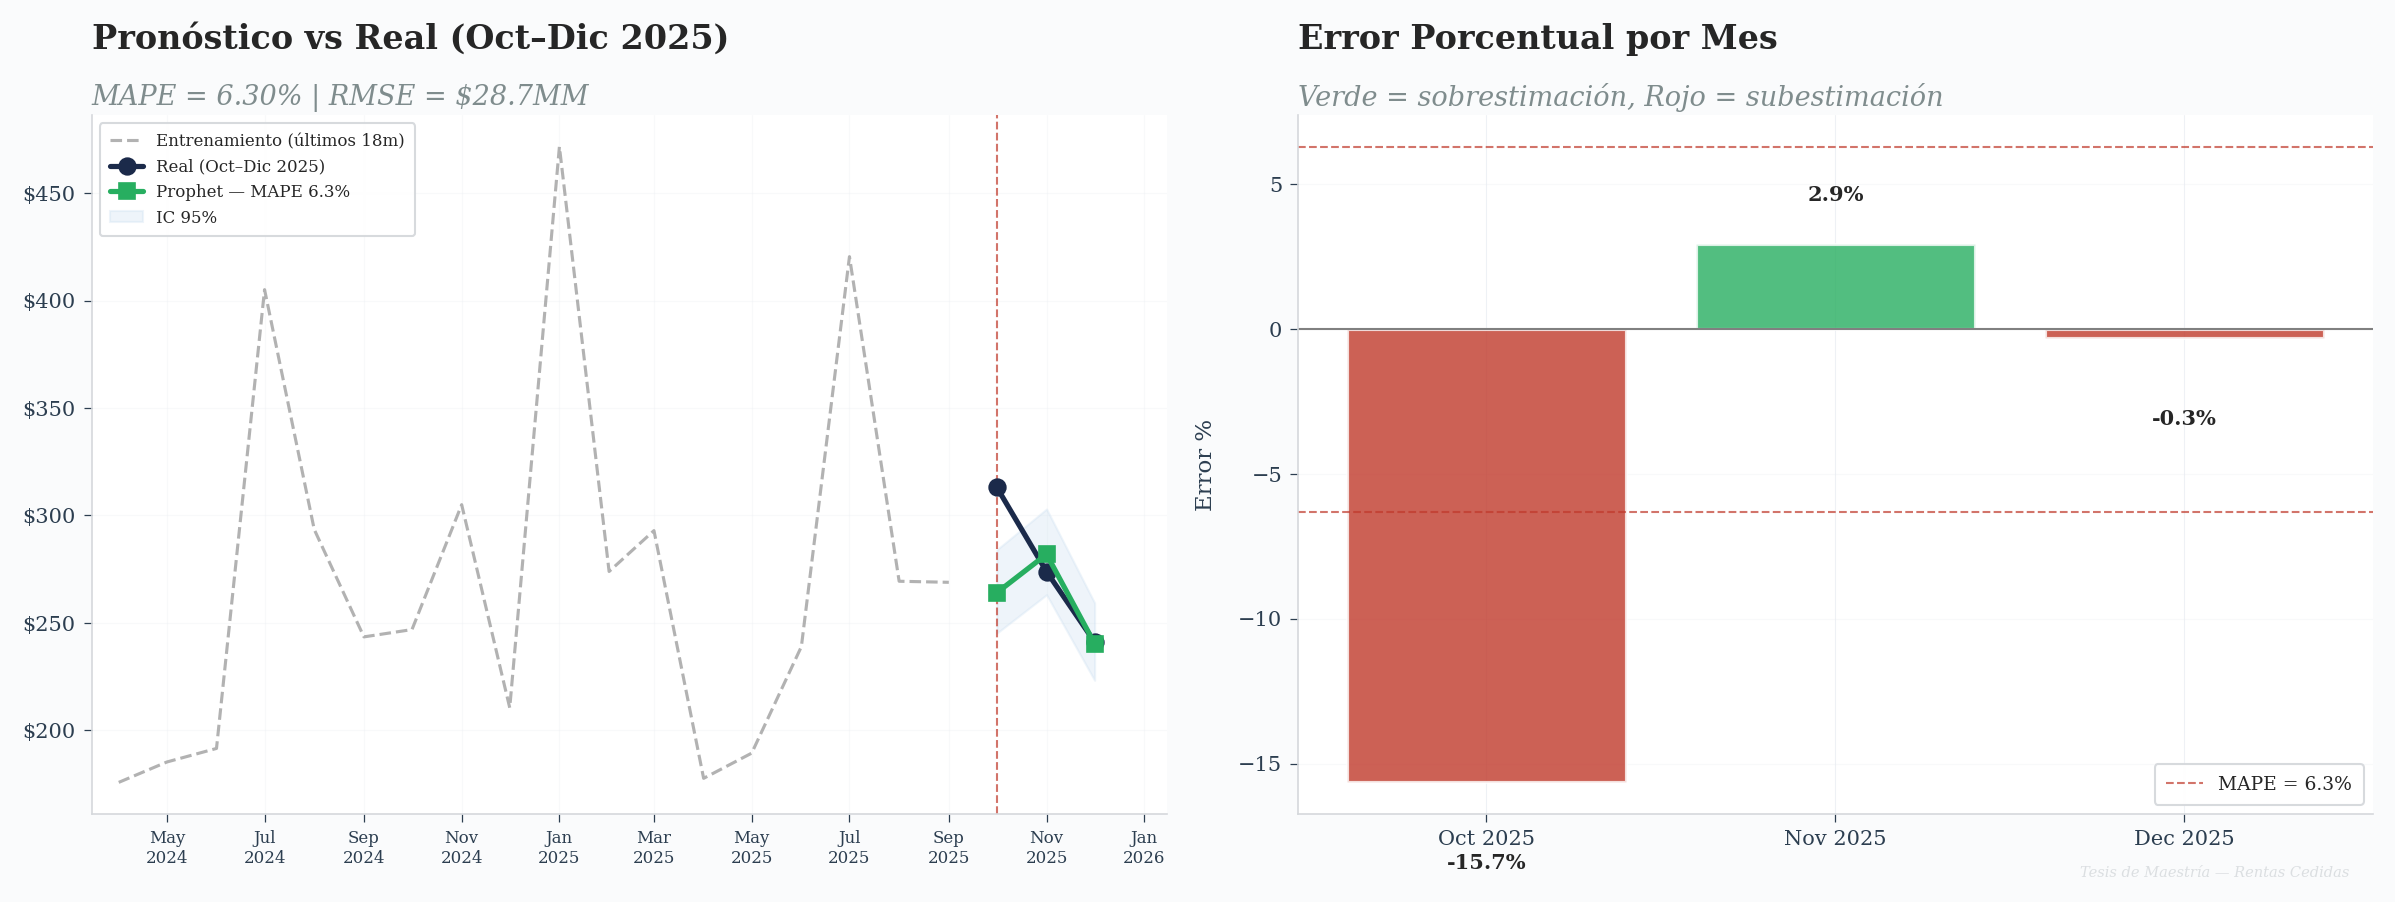


  ✅ Pronóstico OOS guardado: prophet_forecast.csv


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE III — Validación Detallada: Pronóstico vs Real (Oct–Dic 2025)
# ══════════════════════════════════════════════════════════════

print(f"{'═'*70}")
print(f"VALIDACIÓN OUT-OF-SAMPLE — {winner['Config']}")
print(f"{'═'*70}")
print(f"  Periodo: {test.index.min().strftime('%Y-%m')} → {test.index.max().strftime('%Y-%m')} ({len(test)} meses)")
print(f"\n{'─'*70}")
print(f"{'Mes':<12} {'Real':>15} {'Pronóstico':>15} {'Error':>12} {'Error%':>8}")
print(f"{'─'*70}")

for j, fecha in enumerate(test.index):
    real = test.values[j]
    pred = winner['pred'][j]
    err = pred - real
    err_pct = (pred - real) / real * 100
    print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  "
          f"${err/1e9:>10,.1f}MM  {err_pct:>6.1f}%")

print(f"{'─'*70}")
print(f"  MAPE:  {winner['MAPE']:.2f}%")
print(f"  RMSE:  ${winner['RMSE_MM']:.1f} MM COP")
print(f"  MAE:   ${winner['MAE_MM']:.1f} MM COP")

# ── Visualización: Real vs Pronóstico (2 paneles) ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Contexto histórico + OOS
ax = axes[0]
n_hist = min(18, len(train))
ax.plot(train.index[-n_hist:], train.values[-n_hist:]/1e9,
        color='grey', lw=1.5, ls='--', alpha=0.6, label='Entrenamiento (últimos 18m)')
ax.plot(test.index, test.values/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', markersize=8, label='Real (Oct–Dic 2025)', zorder=5)
ax.plot(test.index, winner['pred']/1e9, color=C_QUATERNARY, lw=2.5,
        marker='s', markersize=8, label=f"Prophet — MAPE {winner['MAPE']:.1f}%", zorder=5)
ax.fill_between(test.index, winner['lower']/1e9, winner['upper']/1e9,
                color=C_CI_FILL, alpha=0.3, label='IC 95%', zorder=1)
ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Pronóstico vs Real (Oct–Dic 2025)',
                       f'MAPE = {winner["MAPE"]:.2f}% | RMSE = ${winner["RMSE_MM"]:.1f}MM')
    formato_pesos_eje(ax, eje='y')
else:
    ax.set_title(f'Prophet — Validación OOS (MAPE={winner["MAPE"]:.2f}%)',
                 fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(formato_pesos))

# Panel 2: Barras de error porcentual
ax2 = axes[1]
meses_label = [f.strftime('%b %Y') for f in test.index]
errores_pct = [(winner['pred'][k] - test.values[k]) / test.values[k] * 100
               for k in range(len(test))]
clr_pos, clr_neg = '#27AE60', '#C0392B'
colors_bar = [clr_pos if e >= 0 else clr_neg for e in errores_pct]
ax2.bar(meses_label, errores_pct, color=colors_bar, alpha=0.8,
        edgecolor='white', lw=1.5)
ax2.axhline(0, color='grey', lw=1)
ax2.axhline(winner['MAPE'], color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
            label=f'MAPE = {winner["MAPE"]:.1f}%')
ax2.axhline(-winner['MAPE'], color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
for k, (m, e) in enumerate(zip(meses_label, errores_pct)):
    offset = 1.5 if e >= 0 else -3
    ax2.text(k, e + offset, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Error %', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Error Porcentual por Mes',
                       'Verde = sobrestimación, Rojo = subestimación')
else:
    ax2.set_title('Error % por Mes', fontsize=12, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05_prophet_oos_validacion', OUTPUTS_FIGURES)
else:
    plt.savefig(str(OUTPUTS_FIGURES / '05_prophet_oos_validacion.png'),
                dpi=150, bbox_inches='tight')
plt.show()

# ── Guardar pronóstico OOS (Real vs Predicho) ──
df_oos = pd.DataFrame({
    'Fecha': test.index,
    'Real': test.values,
    'Pronostico_Prophet': winner['pred'],
    'IC_Inferior': winner['lower'],
    'IC_Superior': winner['upper'],
    'Error_Abs': np.abs(winner['pred'] - test.values),
    'Error_Pct': (winner['pred'] - test.values) / test.values * 100
})
df_oos.to_csv(OUTPUTS_FORECASTS / 'prophet_forecast.csv', index=False)
print(f"\n  ✅ Pronóstico OOS guardado: prophet_forecast.csv")

---

## Fase IV — Descomposición de Componentes y Ranking de Configuraciones

Prophet descompone la serie en:
- **Tendencia:** Trayectoria base con changepoints automáticos
- **Estacionalidad anual:** El perfil estacional fiscal (picos Ene/Jul)
- **Regresores** (si aplica): Efecto marginal de variables exógenas

  📊 Figura guardada: 05_prophet_componentes.png


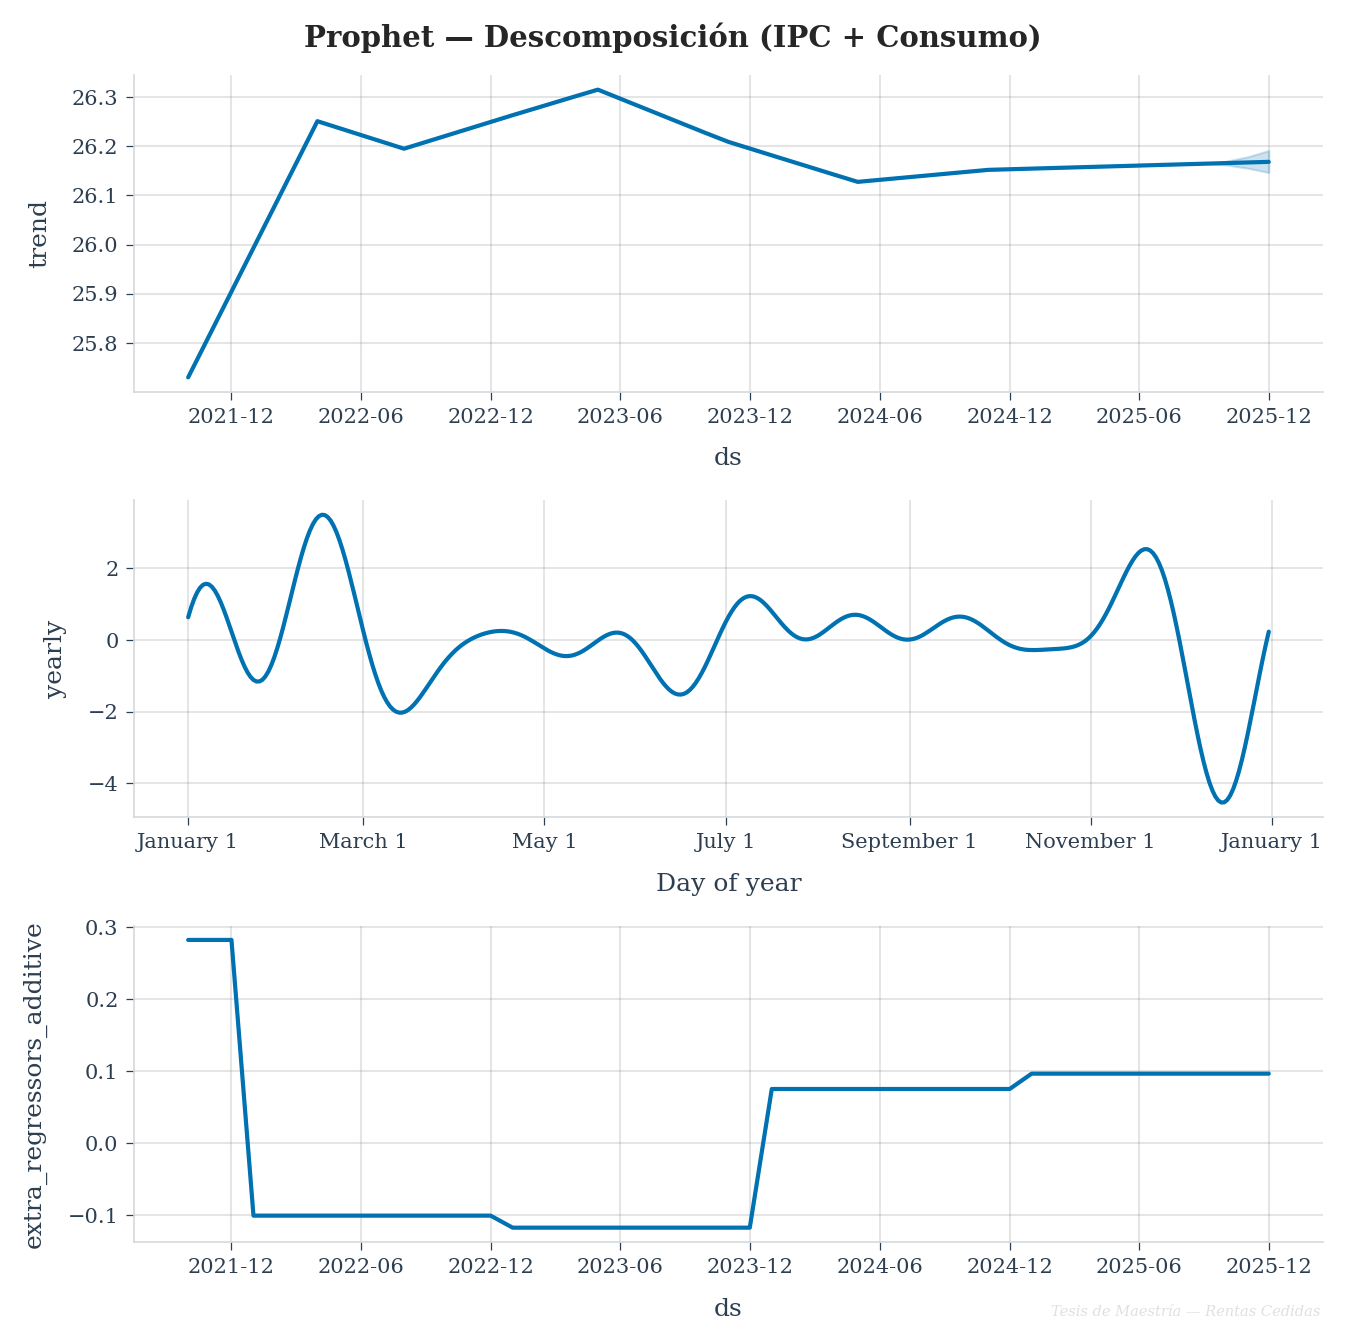

══════════════════════════════════════════════════════════════════════
PUNTOS DE CAMBIO DETECTADOS — IPC + Consumo
══════════════════════════════════════════════════════════════════════
  Total de puntos de cambio evaluados: 25
  Magnitud promedio |Δ|: 0.012904

  Los 5 puntos de cambio más significativos:
    [1] 2022-04 — Δ = -0.176837
    [2] 2023-05 — Δ = -0.053773
    [3] 2022-08 — Δ = +0.048128
    [4] 2024-05 — Δ = +0.030665
    [5] 2023-11 — Δ = +0.006055


  📊 Figura guardada: 05_prophet_comparacion_configs.png


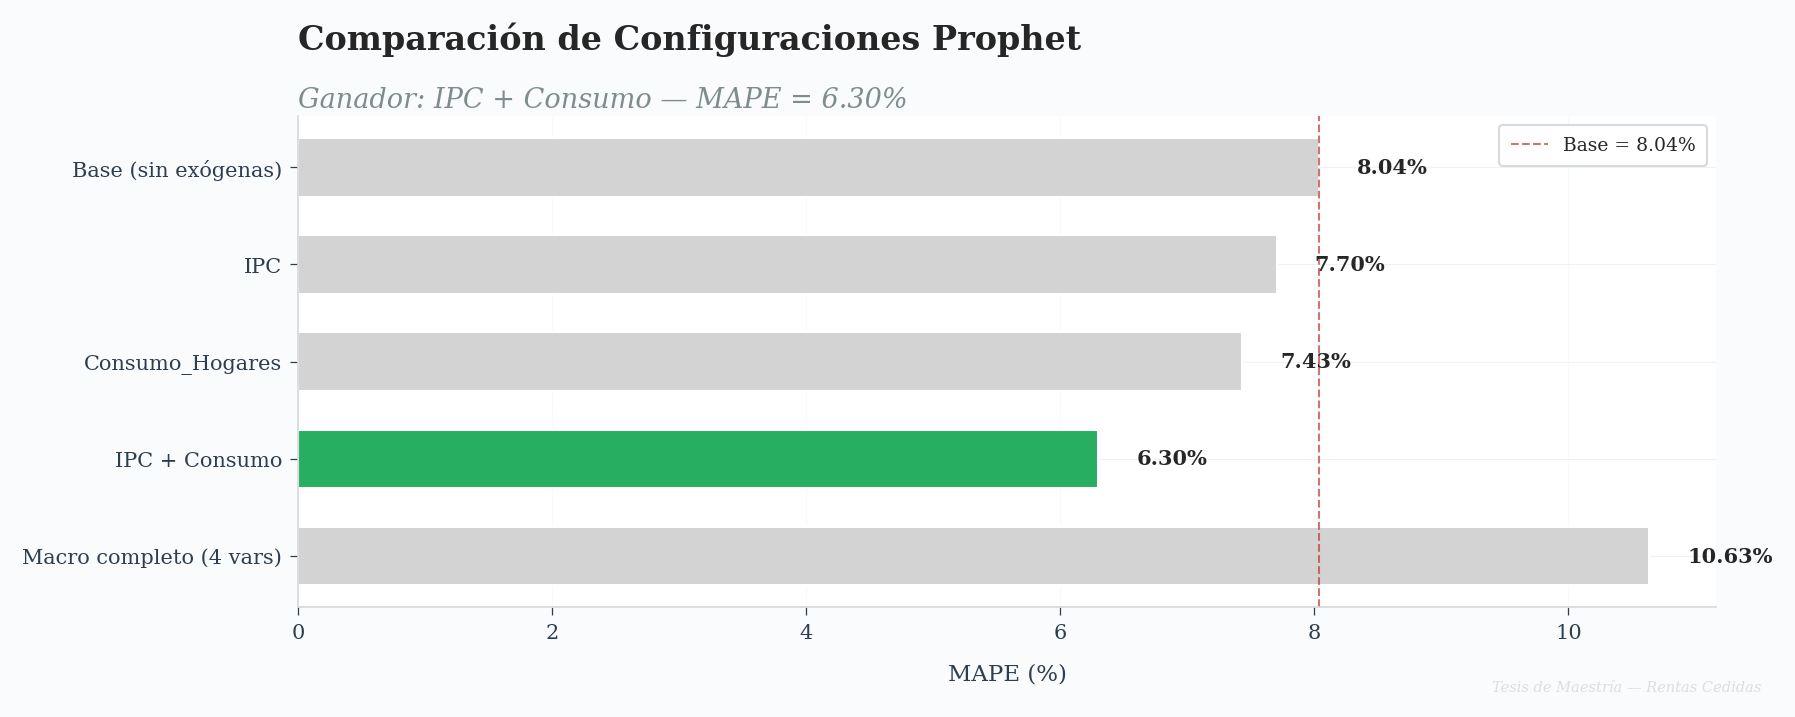

In [4]:
# ══════════════════════════════════════════════════════════════
# FASE IV — Descomposición de Componentes + Ranking Visual
# ══════════════════════════════════════════════════════════════

# ── Componentes del modelo ganador ──
fig_comp = winner['model'].plot_components(winner['forecast'])
fig_comp.suptitle(f"Prophet — Descomposición ({winner['Config']})",
                  fontsize=14, fontweight='bold', y=0.98)
fig_comp.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig_comp)
    guardar_figura(fig_comp, '05_prophet_componentes', OUTPUTS_FIGURES)
else:
    fig_comp.savefig(str(OUTPUTS_FIGURES / '05_prophet_componentes.png'),
                     dpi=150, bbox_inches='tight')
plt.show()

# ── Changepoints detectados ──
deltas = winner['model'].params['delta'].flatten()
cp_dates = winner['model'].changepoints

print(f"{'═'*70}")
print(f"PUNTOS DE CAMBIO DETECTADOS — {winner['Config']}")
print(f"{'═'*70}")
print(f"  Total de puntos de cambio evaluados: {len(cp_dates)}")
print(f"  Magnitud promedio |Δ|: {np.abs(deltas).mean():.6f}")

# Top 5 changepoints más significativos
n_top = min(5, len(deltas))
top_idx = np.argsort(np.abs(deltas))[-n_top:][::-1]
print(f"\n  Los {n_top} puntos de cambio más significativos:")
for rank, idx in enumerate(top_idx, 1):
    print(f"    [{rank}] {cp_dates.iloc[idx].strftime('%Y-%m')} — Δ = {deltas[idx]:+.6f}")

# ── Ranking visual de configuraciones ──
fig, ax = plt.subplots(figsize=(12, 5))
configs_names = [r['Config'] for r in resultados]
mapes = [r['MAPE'] for r in resultados]
colors_rank = [C_QUATERNARY if r['Config'] == winner['Config'] else 'lightgrey'
               for r in resultados]
bars = ax.barh(range(len(configs_names)), mapes, color=colors_rank,
               edgecolor='white', height=0.6)
ax.set_yticks(range(len(configs_names)))
ax.set_yticklabels(configs_names, fontsize=10)
ax.set_xlabel('MAPE (%)', fontsize=11)
ax.invert_yaxis()
for bar, mape_val in zip(bars, mapes):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{mape_val:.2f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(base['MAPE'], color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
           label=f"Base = {base['MAPE']:.2f}%")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Comparación de Configuraciones Prophet',
                       f'Ganador: {winner["Config"]} — MAPE = {winner["MAPE"]:.2f}%')
else:
    ax.set_title('Comparación de Configuraciones Prophet',
                 fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05_prophet_comparacion_configs', OUTPUTS_FIGURES)
else:
    plt.savefig(str(OUTPUTS_FIGURES / '05_prophet_comparacion_configs.png'),
                dpi=150, bbox_inches='tight')
plt.show()

---

## Fase V — Pronóstico de Producción 2026

Se reentrena el modelo ganador con **toda la serie disponible**
(Ene 2022 – Dic 2025, 48 meses) para generar el pronóstico de producción
de 12 meses (Ene – Dic 2026).

> **Nota:** El pronóstico se genera en escala log1p y se retransforma
> a pesos colombianos mediante `expm1()` para interpretación directa.

14:30:47 - cmdstanpy - INFO - Chain [1] start processing


14:30:47 - cmdstanpy - INFO - Chain [1] done processing


══════════════════════════════════════════════════════════════════════
REENTRENAMIENTO CON SERIE COMPLETA Ene 2022 – Dic 2025
══════════════════════════════════════════════════════════════════════
  Modelo: IPC + Consumo
  Observaciones: 51 meses

──────────────────────────────────────────────────────────────────────
PRONÓSTICO PROPHET 2026 — Rentas Cedidas
──────────────────────────────────────────────────────────────────────
Mes               Pronóstico     IC Inferior     IC Superior
──────────────────────────────────────────────────────────────────────
  2026-01    $        455.0MM  $        421.6MM  $        486.9MM
  2026-02    $        255.5MM  $        235.8MM  $        276.4MM
  2026-03    $        363.1MM  $        335.4MM  $        393.5MM
  2026-04    $        192.7MM  $        176.9MM  $        209.1MM
  2026-05    $        211.0MM  $        192.3MM  $        230.6MM
  2026-06    $        239.5MM  $        216.9MM  $        265.0MM
  2026-07    $        414.6MM  $        3

  📊 Figura guardada: 05_prophet_produccion_2026.png


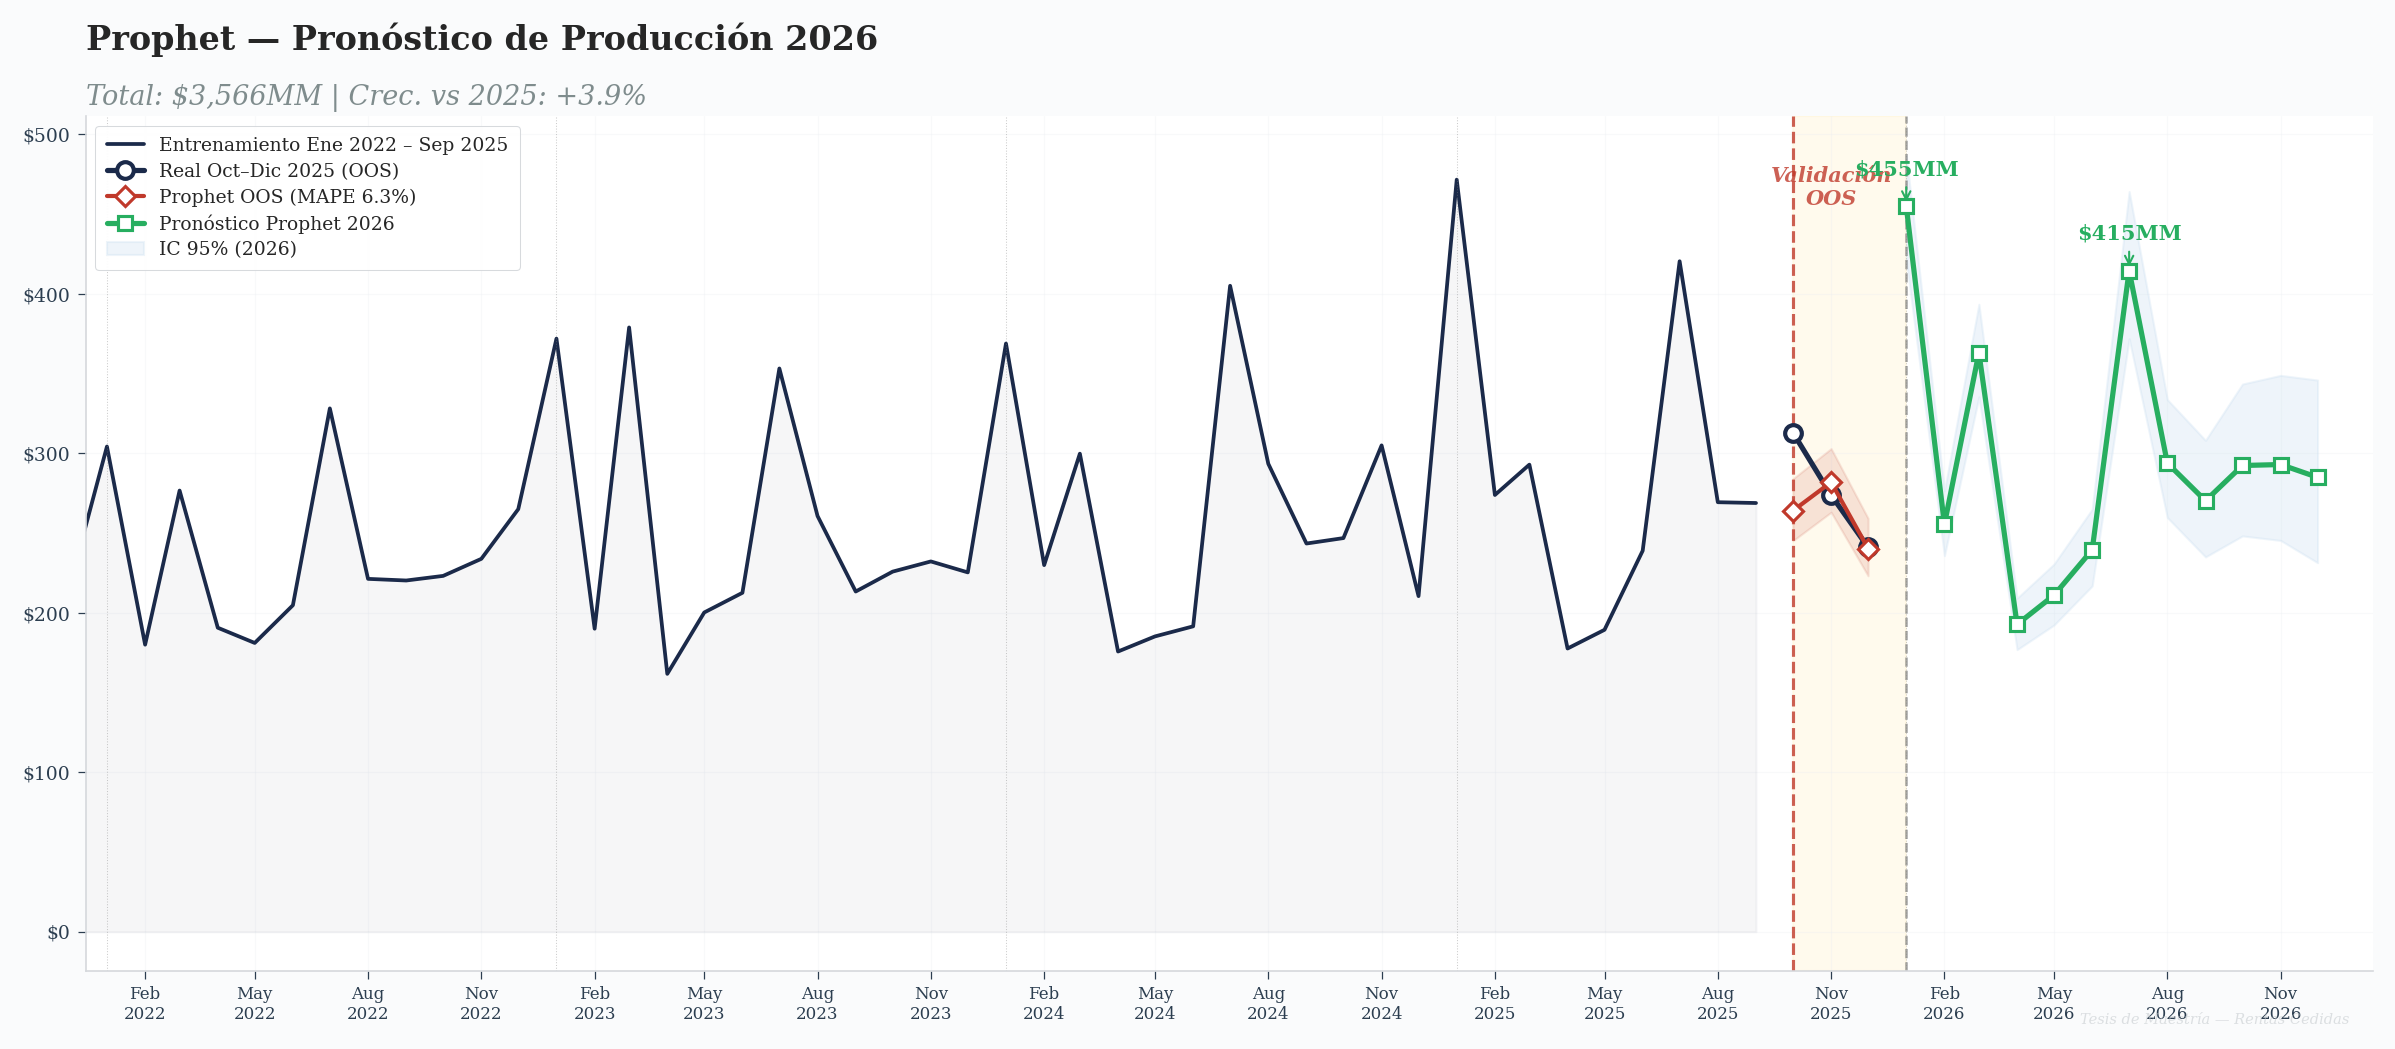


  ✅ Pronóstico producción guardado: prophet_forecast_2026.csv


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE V — Pronóstico de Producción 2026
# ══════════════════════════════════════════════════════════════

HORIZONTE_PRODUCCION = 12  # Ene – Dic 2026 (año fiscal completo)

# ── Reentrenar con serie COMPLETA (Ene 2022 – Dic 2025) en log1p ──
serie_log_full = np.log1p(serie_full)
df_full = pd.DataFrame({'ds': serie_full.index, 'y': serie_log_full.values})

model_prod = Prophet(**PROPHET_PARAMS)

# Agregar regresores del ganador (si tiene)
winner_vars = [c['vars'] for c in CONFIGS if c['nombre'] == winner['Config']][0]
if winner_vars:
    macro_full = asignar_macro(serie_full.index, winner_vars)
    for var in winner_vars:
        model_prod.add_regressor(var)
        df_full[var] = macro_full[var].values

model_prod.fit(df_full)

print(f"{'═'*70}")
print(f"REENTRENAMIENTO CON SERIE COMPLETA Ene 2022 – Dic 2025")
print(f"{'═'*70}")
print(f"  Modelo: {winner['Config']}")
print(f"  Observaciones: {len(serie_log_full)} meses")

# ── Generar pronóstico 12 meses (2026) ──
future_prod = model_prod.make_future_dataframe(periods=HORIZONTE_PRODUCCION, freq='MS')
if winner_vars:
    macro_future = asignar_macro(future_prod['ds'], winner_vars)
    for var in winner_vars:
        future_prod[var] = macro_future[var].values

forecast_prod = model_prod.predict(future_prod)
fc_2026 = forecast_prod.tail(HORIZONTE_PRODUCCION)

# Retransformar a pesos
pred_2026 = np.expm1(fc_2026['yhat'].values)
ci_lower_2026 = np.maximum(0, np.expm1(fc_2026['yhat_lower'].values))
ci_upper_2026 = np.expm1(fc_2026['yhat_upper'].values)
dates_2026 = pd.DatetimeIndex(fc_2026['ds'].values)

# ── Tabla de pronóstico ──
print(f"\n{'─'*70}")
print(f"PRONÓSTICO PROPHET 2026 — Rentas Cedidas")
print(f"{'─'*70}")
print(f"{'Mes':<12} {'Pronóstico':>15} {'IC Inferior':>15} {'IC Superior':>15}")
print(f"{'─'*70}")
total_2026 = 0
for k in range(HORIZONTE_PRODUCCION):
    fecha = dates_2026[k]
    print(f"  {fecha.strftime('%Y-%m'):<10} ${pred_2026[k]/1e9:>13,.1f}MM  "
          f"${ci_lower_2026[k]/1e9:>13,.1f}MM  ${ci_upper_2026[k]/1e9:>13,.1f}MM")
    total_2026 += pred_2026[k]

print(f"{'─'*70}")
print(f"  {'TOTAL 2026':<10} ${total_2026/1e9:>13,.1f}MM")

# ── Comparación con 2025 ──
total_2025 = serie_full.loc['2025-01-01':'2025-12-31'].sum()
crec = (total_2026 - total_2025) / total_2025 * 100
print(f"\n  Total 2025 (Ene–Dic): ${total_2025/1e9:,.1f}MM")
print(f"  Crecimiento proyectado: {crec:+.1f}%")

# ── Visualización ──
fig, ax = plt.subplots(figsize=(16, 7))

# Entrenamiento (Ene 2022 – Sep 2025)
ax.plot(train.index, train.values/1e9, color=C_PRIMARY, lw=1.8,
        label='Entrenamiento Ene 2022 – Sep 2025')
ax.fill_between(train.index, 0, train.values/1e9, alpha=0.04, color=C_PRIMARY)

# ── Zona OOS delimitada: Oct–Dic 2025 ──
ax.axvspan(pd.Timestamp('2025-10-01'), pd.Timestamp('2026-01-01'),
           color='#FFF3CD', alpha=0.35, zorder=0)
ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1.5, alpha=0.8)
ax.axvline(pd.Timestamp('2026-01-01'), color='grey', ls='--', lw=1.2, alpha=0.7)

# Real OOS
ax.plot(test.index, test.values/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', markersize=8, markerfacecolor='white', markeredgecolor=C_PRIMARY,
        markeredgewidth=2, label='Real Oct–Dic 2025 (OOS)', zorder=5)
# Predicción OOS Prophet
ax.plot(test.index, winner['pred']/1e9, color=C_SECONDARY, lw=2,
        marker='D', markersize=7, markerfacecolor='white', markeredgecolor=C_SECONDARY,
        markeredgewidth=1.5, label=f'Prophet OOS (MAPE {winner["MAPE"]:.1f}%)', zorder=5)
# IC OOS
ax.fill_between(test.index, winner['lower']/1e9, winner['upper']/1e9,
                color=C_SECONDARY, alpha=0.12, zorder=1)

# Etiqueta zona OOS
ax.text(pd.Timestamp('2025-11-01'), ax.get_ylim()[1]*0.92,
        'Validación\nOOS', ha='center', fontsize=10, fontweight='bold',
        color=C_SECONDARY, alpha=0.8, style='italic')

# Pronóstico 2026
ax.plot(dates_2026, pred_2026/1e9, color=C_QUATERNARY, lw=2.5,
        marker='s', markersize=7, markerfacecolor='white', markeredgecolor=C_QUATERNARY,
        markeredgewidth=1.5, label='Pronóstico Prophet 2026', zorder=5)

# IC 95% 2026
ax.fill_between(dates_2026, ci_lower_2026/1e9, ci_upper_2026/1e9,
                color=C_CI_FILL, alpha=0.3, label='IC 95% (2026)', zorder=1)

# Anotar picos (Ene y Jul 2026)
for m_pico in MESES_PICO:
    fecha_pico = pd.Timestamp(f'2026-{m_pico:02d}-01')
    mask = dates_2026 == fecha_pico
    if mask.any():
        idx_p = np.where(mask)[0][0]
        ax.annotate(f'${pred_2026[idx_p]/1e9:.0f}MM',
                    xy=(fecha_pico, pred_2026[idx_p]/1e9),
                    xytext=(0, 15), textcoords='offset points',
                    fontsize=10, fontweight='bold', color=C_QUATERNARY,
                    ha='center',
                    arrowprops=dict(arrowstyle='->', color=C_QUATERNARY, lw=1))

# Formato
ax.set_xlim(pd.Timestamp('2021-12-15'), pd.Timestamp('2027-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=9)
for y_sep in range(2022, 2027):
    ax.axvline(pd.Timestamp(f'{y_sep}-01-01'), color='grey', ls=':', lw=0.5, alpha=0.4)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9, ncol=2)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Prophet — Pronóstico de Producción 2026',
                       f'Total: ${total_2026/1e9:,.0f}MM | Crec. vs 2025: {crec:+.1f}%')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')
else:
    ax.set_title(f'Prophet — Pronóstico 2026 (Total: ${total_2026/1e9:,.0f}MM)',
                 fontsize=14, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(formato_pesos))

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '05_prophet_produccion_2026', OUTPUTS_FIGURES)
else:
    plt.savefig(str(OUTPUTS_FIGURES / '05_prophet_produccion_2026.png'),
                dpi=150, bbox_inches='tight')
plt.show()

# ── Exportar pronóstico de producción ──
df_prod = pd.DataFrame({
    'Fecha': dates_2026,
    'Pronóstico': pred_2026,
    'Limite_Inferior': ci_lower_2026,
    'Limite_Superior': ci_upper_2026
})
df_prod.to_csv(OUTPUTS_FORECASTS / 'prophet_forecast_2026.csv', index=False)
print(f"\n  ✅ Pronóstico producción guardado: prophet_forecast_2026.csv")

---

## Conclusiones del Modelado Prophet

### Decisiones Metodológicas Justificadas

1. **Verificación empírica de exógenas:** La comparación sistemática de 5
   configuraciones determina objetivamente si IPC, SMLV, UPC y Consumo_Hogares
   mejoran la predicción. Si la mejora en MAPE es < 1 pp, se aplica el
   principio de parsimonia y se descarta la complejidad adicional.

2. **Transformación log1p:** Convierte la estacionalidad multiplicativa
   (picos proporcionales al volumen) en aditiva, facilitando la estimación
   robusta de Prophet. Consistente con el enfoque de SARIMAX.

3. **Changepoints conservadores:** `changepoint_prior_scale=0.05` evita
   sobreajuste a picos artificiales derivados de la migración ERP
   (Dynamics → Oracle) durante 2025.

4. **Validación inamovible:** Oct–Dic 2025 como test set permite comparar
   el pronóstico con datos REALES observados, no simulados.

### Siguiente paso

→ **NB 07 (XGBoost):** Modelado basado en árboles con features de calendario
  y regresores lag, para capturar no-linealidades que los modelos lineales
  (SARIMAX, Prophet) no detectan.

In [6]:
# ══════════════════════════════════════════════════════════════
# RESUMEN EJECUTIVO — Métricas y Exportación Final
# ══════════════════════════════════════════════════════════════

metricas = {
    'Modelo': 'Prophet',
    'Config': winner['Config'],
    'Transformacion': 'log1p',
    'Serie': f"Ene 2022 – Dic 2025 ({len(serie_full)} meses)",
    'Train': f"{len(train)} meses",
    'Test': f"{len(test)} meses",
    'MAPE': round(winner['MAPE'], 2),
    'RMSE_MM': round(winner['RMSE_MM'], 1),
    'MAE_MM': round(winner['MAE_MM'], 1),
    'Total_2026_MM': round(total_2026 / 1e9, 1),
    'Crec_vs_2025': round(crec, 1),
    'Exogenas': winner['Variables'],
    'Configs_evaluadas': len(CONFIGS),
}

# Exportar métricas
df_metricas = pd.DataFrame([metricas])
metricas_path = OUTPUTS_REPORTS / 'prophet_metricas.csv'
df_metricas.to_csv(metricas_path, index=False)

# Exportar comparación de configuraciones
df_rank.to_csv(OUTPUTS_REPORTS / 'prophet_configs_comparacion.csv')

print(f"{'═'*70}")
print(f"RESUMEN EJECUTIVO — MODELO PROPHET")
print(f"{'═'*70}")
for k, v in metricas.items():
    print(f"  {k:<20}: {v}")
print(f"\n  ✅ Métricas exportadas:  {metricas_path.name}")
print(f"  ✅ Pronóstico OOS:      prophet_forecast.csv")
print(f"  ✅ Pronóstico 2026:     prophet_forecast_2026.csv")
print(f"  ✅ Comparación configs:  prophet_configs_comparacion.csv")

══════════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO — MODELO PROPHET
══════════════════════════════════════════════════════════════════════
  Modelo              : Prophet
  Config              : IPC + Consumo
  Transformacion      : log1p
  Serie               : Ene 2022 – Dic 2025 (51 meses)
  Train               : 48 meses
  Test                : 3 meses
  MAPE                : 6.3
  RMSE_MM             : 28.7
  MAE_MM              : 19.3
  Total_2026_MM       : 3565.8
  Crec_vs_2025        : 3.9
  Exogenas            : IPC, Consumo_Hogares
  Configs_evaluadas   : 5

  ✅ Métricas exportadas:  prophet_metricas.csv
  ✅ Pronóstico OOS:      prophet_forecast.csv
  ✅ Pronóstico 2026:     prophet_forecast_2026.csv
  ✅ Comparación configs:  prophet_configs_comparacion.csv
